In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "../data/cleaned/online_retail_cleaned.csv",
    parse_dates=["InvoiceDate", "Month_Start"]
)

print(df.shape)

(1033036, 17)


In [2]:
sales_df = df[
    (df["Is_Return"] == False) &
    (df["Quantity"] > 0) &
    (df["Price"] > 0)
].copy()

print("Sales records:", len(sales_df))

Sales records: 1007913


In [3]:
sales_df[["Quantity", "Price", "Revenue"]].describe()

,Quantity,Price,Revenue
count,1.007913e+06,1.007913e+06,1.007913e+06
mean,1.111718e+01,4.074252e+00,2.031550e+01
std,1.284700e+02,5.043045e+01,2.057158e+02
min,1.000000e+00,1.000000e-03,1.000000e-03
25%,1.000000e+00,1.250000e+00,4.130000e+00
50%,4.000000e+00,2.100000e+00,1.008000e+01
75%,1.200000e+01,4.130000e+00,1.770000e+01
max,8.099500e+04,2.511109e+04,1.684696e+05


In [4]:
metrics = {
    "Revenue Mean": sales_df["Revenue"].mean(),
    "Revenue Median": sales_df["Revenue"].median(),
    "Revenue Std": sales_df["Revenue"].std(),
    "Quantity Mean": sales_df["Quantity"].mean(),
    "Quantity Median": sales_df["Quantity"].median()
}

metrics

{'Revenue Mean': np.float64(20.31550386590906),
 'Revenue Median': np.float64(10.08),
 'Revenue Std': np.float64(205.7158284834619),
 'Quantity Mean': np.float64(11.117177772287887),
 'Quantity Median': np.float64(4.0)}

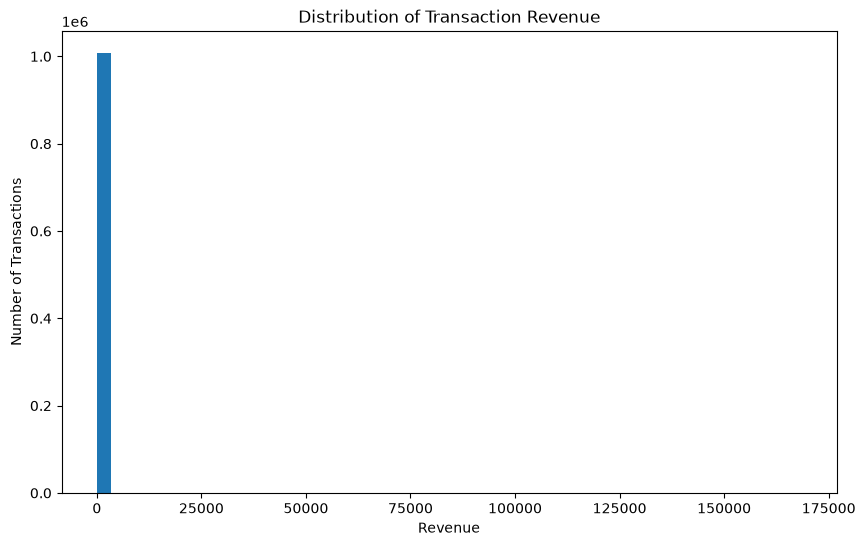

In [5]:
plt.figure(figsize=(10, 6))

plt.hist(
    sales_df["Revenue"],
    bins=50
)

plt.title("Distribution of Transaction Revenue")
plt.xlabel("Revenue")
plt.ylabel("Number of Transactions")

plt.show()

In [6]:
Q1 = sales_df["Revenue"].quantile(0.25)
Q3 = sales_df["Revenue"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 4.13
Q3: 17.700000000000003
IQR: 13.570000000000004
Lower Bound: -16.225000000000005
Upper Bound: 38.05500000000001


In [7]:
outliers = sales_df[
    (sales_df["Revenue"] < lower_bound) |
    (sales_df["Revenue"] > upper_bound)
]

print("Number of revenue outliers:", len(outliers))

Number of revenue outliers: 84954


In [8]:
customer_stats = (
    sales_df
    .dropna(subset=["Customer_ID"])
    .groupby("Customer_ID")
    .agg(
        Total_Spend=("Revenue", "sum"),
        Total_Orders=("Invoice", "nunique"),
        Total_Quantity=("Quantity", "sum")
    )
)

customer_stats.describe()

,Total_Spend,Total_Orders,Total_Quantity
count,5878.000000,5878.000000,5878.000000
mean,2955.904095,6.289384,1788.695475
std,14440.852688,13.009406,8876.297196
min,2.950000,1.000000,1.000000
25%,342.280000,1.000000,187.000000
50%,867.740000,3.000000,480.000000
75%,2248.305000,7.000000,1350.000000
max,580987.040000,398.000000,367193.000000


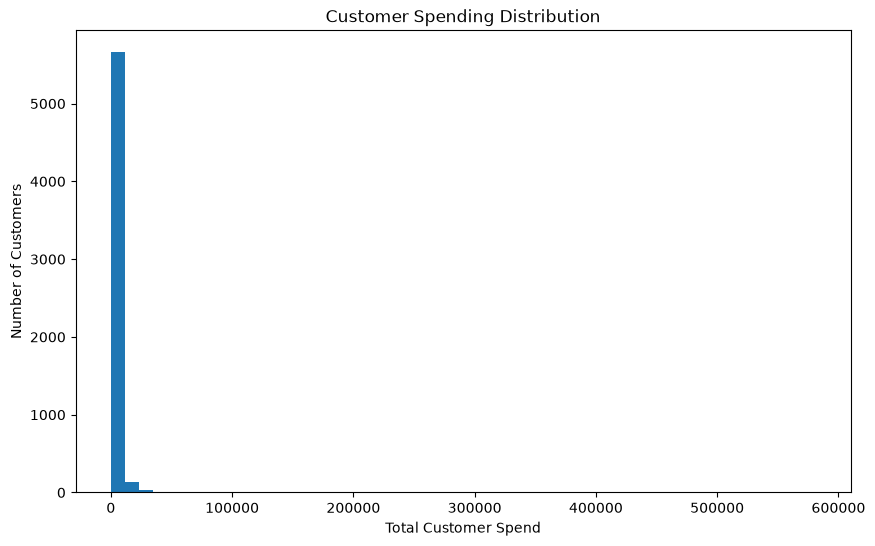

In [9]:
plt.figure(figsize=(10, 6))

plt.hist(
    customer_stats["Total_Spend"],
    bins=50
)

plt.title("Customer Spending Distribution")
plt.xlabel("Total Customer Spend")
plt.ylabel("Number of Customers")

plt.show()

In [10]:
sales_df["Day_of_Week"].value_counts()

Day_of_Week
Thursday     190465
Tuesday      186402
Monday       179603
Wednesday    173059
Friday       146072
Sunday       131912
Saturday        400
Name: count, dtype: int64

In [11]:
sales_df["Is_Weekend"] = (
    sales_df["InvoiceDate"].dt.dayofweek >= 5
)

In [12]:
sales_df["Is_Weekend"].value_counts()

Is_Weekend
False    875601
True     132312
Name: count, dtype: int64

In [13]:
sales_df["Order_Value_Category"] = pd.cut(
    sales_df["Revenue"],
    bins=[-np.inf, 20, 100, 500, np.inf],
    labels=[
        "Low Value",
        "Medium Value",
        "High Value",
        "Very High Value"
    ]
)

In [14]:
sales_df["Order_Value_Category"].value_counts()

Order_Value_Category
Low Value          812900
Medium Value       168590
High Value          24167
Very High Value      2256
Name: count, dtype: int64

In [15]:
correlation = sales_df[
    ["Quantity", "Price", "Revenue"]
].corr()

correlation

,Quantity,Price,Revenue
Quantity,1.000000,-0.003855,0.806920
Price,-0.003855,1.000000,0.247036
Revenue,0.806920,0.247036,1.000000


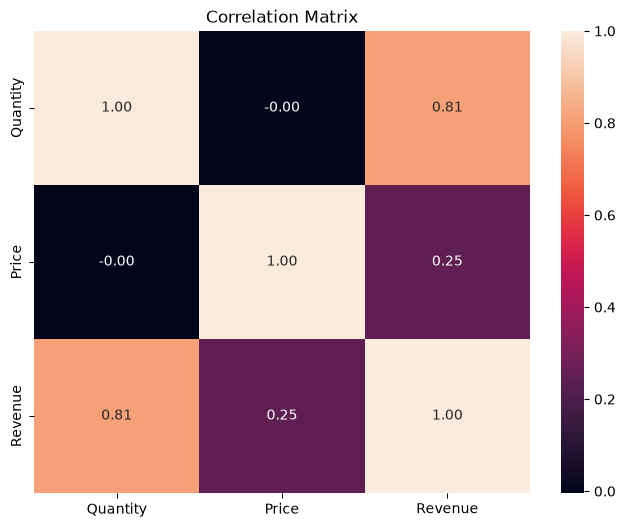

In [16]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [17]:
day_revenue = (
    sales_df
    .groupby("Day_of_Week")["Revenue"]
    .sum()
)

In [18]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_revenue = day_revenue.reindex(day_order)

day_revenue

Day_of_Week
Monday       3581594.176
Tuesday      4078149.962
Wednesday    3488444.333
Thursday     4195212.762
Friday       3323908.883
Saturday        9803.050
Sunday       1799147.282
Name: Revenue, dtype: float64

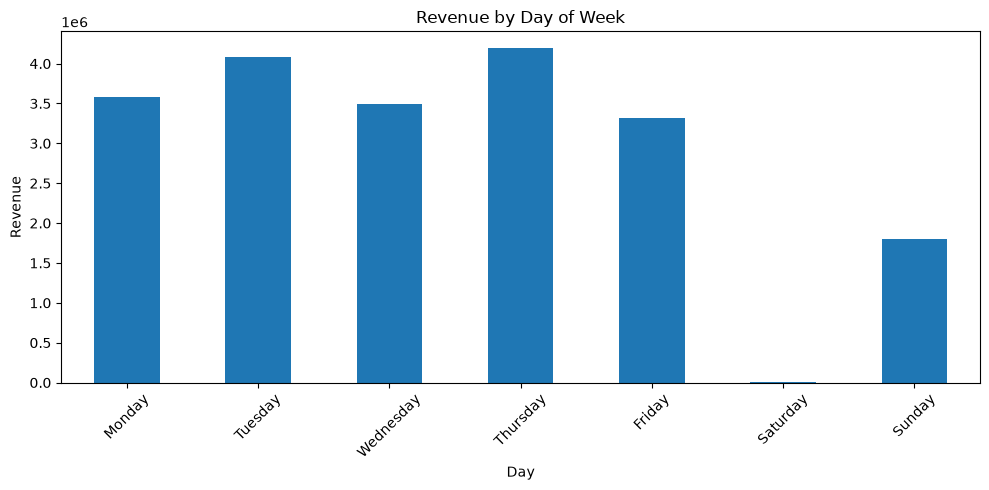

In [19]:
plt.figure(figsize=(10, 5))

day_revenue.plot(kind="bar")

plt.title("Revenue by Day of Week")
plt.xlabel("Day")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
quarter_revenue = (
    sales_df
    .groupby(["Year", "Quarter"])["Revenue"]
    .sum()
    .reset_index()
)

quarter_revenue

,Year,Quarter,Revenue
0,2009,4,822483.950
1,2010,1,2033575.099
2,2010,2,2086118.062
3,2010,3,2265759.171
4,2010,4,3447648.092
5,2011,1,1928572.430
6,2011,2,2066812.111
7,2011,3,2532352.693
8,2011,4,3292938.840


In [21]:
analysis_date = sales_df["InvoiceDate"].max()

print("Analysis Date:", analysis_date)

Analysis Date: 2011-12-09 12:50:00


In [22]:
rfm = (
    sales_df
    .dropna(subset=["Customer_ID"])
    .groupby("Customer_ID")
    .agg(
        Recency=(
            "InvoiceDate",
            lambda x: (analysis_date - x.max()).days
        ),
        Frequency=("Invoice", "nunique"),
        Monetary=("Revenue", "sum")
    )
    .reset_index()
)

rfm.head()

,Customer_ID,Recency,Frequency,Monetary
0,12346.0,325,12,77556.46
1,12347.0,1,8,4921.53
2,12348.0,74,5,2019.40
3,12349.0,18,4,4428.69
4,12350.0,309,1,334.40


In [23]:
rfm.describe()

,Customer_ID,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,15315.313542,200.331916,6.289384,2955.904095
std,1715.572666,209.338707,13.009406,14440.852688
min,12346.000000,0.000000,1.000000,2.950000
25%,13833.250000,25.000000,1.000000,342.280000
50%,15314.500000,95.000000,3.000000,867.740000
75%,16797.750000,379.000000,7.000000,2248.305000
max,18287.000000,738.000000,398.000000,580987.040000


In [24]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

In [25]:
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

In [26]:
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

In [27]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

In [28]:
def segment_customer(row):

    if row["R_Score"] >= 4 and row["F_Score"] >= 4 and row["M_Score"] >= 4:
        return "Champions"

    elif row["R_Score"] >= 3 and row["F_Score"] >= 3:
        return "Loyal Customers"

    elif row["R_Score"] >= 4 and row["F_Score"] <= 2:
        return "New Customers"

    elif row["R_Score"] <= 2 and row["F_Score"] >= 3:
        return "At Risk"

    elif row["R_Score"] <= 2 and row["F_Score"] <= 2:
        return "Lost Customers"

    else:
        return "Potential Loyalists"


rfm["Customer_Segment"] = rfm.apply(
    segment_customer,
    axis=1
)

In [29]:
rfm["Customer_Segment"].value_counts()

Customer_Segment
Lost Customers         1526
Loyal Customers        1413
Champions              1289
At Risk                 825
New Customers           441
Potential Loyalists     384
Name: count, dtype: int64

In [30]:
segment_analysis = (
    rfm
    .groupby("Customer_Segment")
    .agg(
        Customers=("Customer_ID", "count"),
        Revenue=("Monetary", "sum"),
        Avg_Spend=("Monetary", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Recency=("Recency", "mean")
    )
    .sort_values("Revenue", ascending=False)
)

segment_analysis

,Customers,Revenue,Avg_Spend,Avg_Frequency,Avg_Recency
Customer_Segment,,,,,
Champions,1289,1.181963e+07,9169.609678,17.146625,18.719162
Loyal Customers,1413,2.713749e+06,1920.558631,5.457183,70.133050
At Risk,825,1.590385e+06,1927.738887,4.941818,367.882424
Lost Customers,1526,6.554447e+05,429.518140,1.252949,457.749672
New Customers,441,3.918383e+05,888.522132,1.460317,26.965986
Potential Loyalists,384,2.037605e+05,530.626362,1.361979,105.216146


In [31]:
rfm.to_csv(
    "../data/cleaned/customer_rfm.csv",
    index=False
)

segment_analysis.to_csv(
    "../data/cleaned/customer_segments.csv"
)

print("RFM analysis saved successfully!")

RFM analysis saved successfully!
